# Valuation Toolkit — Walkthrough: Microsoft (MSFT)

This notebook runs the full toolkit end to end on a single real company:
a **DCF**, **trading comparables**, and **precedent transactions**
valuation, then a **credit overlay** that turns each method's Enterprise
Value into a leverage capacity and downside recovery view — the question a
direct lender or leveraged-finance analyst actually asks: *what can this
company support in debt, and what do you get back if it doesn't work out?*

Microsoft was chosen because it has clean, unambiguous historical
financials and a genuine, liquid trading-comps peer set — useful properties
for demonstrating each method clearly. It is also, deliberately, not the
most *dramatic* company to run a credit overlay on: at MSFT's scale even
significant leverage carries a large equity cushion, and that turns out to
be one of the more interesting findings below, not a limitation of the
tool. See [`LIMITATIONS.md`](../LIMITATIONS.md) in the repo root for every
simplification and open question behind this toolkit, stated explicitly.

## Setup

In [1]:
import sys
sys.path.insert(0, "..")

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from data.fetch import build_company, cache_age
from valuation import utils, dcf, comps, precedent_transactions as pt, credit_overlay as co

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
TICKER = "MSFT"
company = build_company(TICKER)
print(company)
print(f"Sector: {company.sector} | Currency: {company.currency} (financials in {company.financial_currency})")
print(f"Data cache age: {cache_age(TICKER)}  (None = freshly fetched this run)")

Company(ticker='MSFT', name='MSFT', sector='Technology')
Sector: Technology | Currency: USD (financials in USD)
Data cache age: None  (None = freshly fetched this run)


## 1. Company snapshot & historical unlevered free cash flow

Before projecting anything forward, build UFCF for the years already
reported — the same explicit EBIT → NOPAT → +D&A → −Capex → −ΔNWC waterfall
the DCF projection will reuse, so historical and projected cash flow are
built on identical logic.

In [2]:
hist_ufcf = company.compute_historical_ufcf()
hist_ufcf

,revenue,ebit,tax_rate,nopat,d_and_a,capex,delta_nwc,ufcf
2023,"211,915,000,000.00","91,279,000,000.00",0.19,"73,935,990,000.00","13,861,000,000.00","28,107,000,000.00",NaN,NaN
2024,"245,122,000,000.00","110,722,000,000.00",0.18,"90,535,940,014.00","20,958,000,000.00","44,477,000,000.00","-45,660,000,000.00","112,676,940,014.00"
2025,"281,724,000,000.00","126,012,000,000.00",0.18,"103,796,588,448.00","29,433,000,000.00","64,551,000,000.00","15,465,000,000.00","53,213,588,448.00"
2026,"331,839,000,000.00","168,985,000,000.00",0.19,"136,201,910,000.00","38,534,000,000.00","115,948,000,000.00","-11,028,000,000.00","69,815,910,000.00"


In [3]:
# Sanity-check the DCF's assumed forward growth against what actually happened
first_year, last_year = company.financials.index[0], company.financials.index[-1]
revenue_cagr = utils.cagr(
    company.financials.loc[first_year, "revenue"],
    company.financials.loc[last_year, "revenue"],
    last_year - first_year,
)
print(f"Historical revenue CAGR ({first_year}-{last_year}): {revenue_cagr:.1%}")
print(f"(Compare against the Year-1 forward growth assumption in Section 2 below.)")

Historical revenue CAGR (2023-2026): 16.1%
(Compare against the Year-1 forward growth assumption in Section 2 below.)


## 2. Discounted Cash Flow

Five-year UFCF projection driven by explicit, reusable assumptions (not
hardcoded per company), a CAPM/WACC build-up shown in full, and **both**
terminal value methods side by side — Gordon Growth and Exit Multiple —
so the two can be compared directly rather than picking one and hiding the
other.

In [4]:
assumptions = {
    "years": 5,
    "revenue_growth": [0.13, 0.11, 0.10, 0.09, 0.08],   # fading toward a mature long-run rate
    "ebitda_margin":  [0.50, 0.50, 0.51, 0.51, 0.52],    # modest continued operating leverage
    "da_pct_revenue": 0.05,
    "capex_pct_revenue": 0.13,
    "nwc_pct_revenue": 0.05,
}

projection = dcf.project_ufcf(company, assumptions)
projection

,revenue,ebitda,d_and_a,ebit,tax_rate,nopat,capex,nwc,delta_nwc,ufcf
2027,"374,978,070,000.00","187,489,035,000.00","18,748,903,500.00","168,740,131,500.00",0.19,"136,004,545,989.00","48,747,149,100.00","18,748,903,500.00","-20,136,096,500.00","126,142,396,889.00"
2028,"416,225,657,700.00","208,112,828,850.00","20,811,282,885.00","187,301,545,965.00",0.19,"150,965,046,047.79","54,109,335,501.00","20,811,282,885.00","2,062,379,385.00","115,604,614,046.79"
2029,"457,848,223,470.00","233,502,593,969.70","22,892,411,173.50","210,610,182,796.20",0.19,"169,751,807,333.74","59,520,269,051.10","22,892,411,173.50","2,081,128,288.50","131,042,821,167.64"
2030,"499,054,563,582.30","254,517,827,426.97","24,952,728,179.12","229,565,099,247.86",0.19,"185,029,469,993.77","64,877,093,265.70","24,952,728,179.12","2,060,317,005.62","143,044,787,901.57"
2031,"538,978,928,668.88","280,269,042,907.82","26,948,946,433.44","253,320,096,474.38",0.19,"204,175,997,758.35","70,067,260,726.95","26,948,946,433.44","1,996,218,254.33","159,061,465,210.51"


In [5]:
wacc_inputs = {
    "risk_free_rate": 0.04,          # ~US 10-year Treasury yield
    "equity_risk_premium": 0.05,     # long-run US equity risk premium
    "cost_of_debt_pre_tax": 0.045,   # approximate pre-tax borrowing cost for a high-grade issuer
    "beta": 0.9,                     # manual override; omit to pull Yahoo Finance's reported beta instead
}
wacc_breakdown = dcf.compute_wacc(company, **wacc_inputs)
pd.Series(wacc_breakdown, name="WACC build-up").to_frame()

,WACC build-up
risk_free_rate,0.04
beta,0.90
equity_risk_premium,0.05
cost_of_equity,0.09
cost_of_debt_pre_tax,0.04
tax_rate,0.19
cost_of_debt_after_tax,0.04
market_value_equity,"3,720,346,801,900.82"
market_value_debt,"19,359,000,000.00"
equity_weight,0.99


In [6]:
result = dcf.run_dcf(
    company,
    assumptions,
    wacc_inputs,
    terminal_growth_rate=0.03,   # <= long-run GDP growth, per Gordon Growth's own validity requirement
    exit_multiple=14.0,          # roughly today's large-cap software trading multiple
)
result.summary()

,Gordon Growth,Exit Multiple
Terminal value (undiscounted),"2,992,512,528,764.28","3,923,766,600,709.48"
PV of terminal value,"1,992,471,875,579.73","2,612,518,585,337.74"
PV of explicit-period UFCF,"526,419,656,836.11","526,419,656,836.11"
Enterprise Value,"2,518,891,532,415.84","3,138,938,242,173.85"
Equity Value,"2,499,532,532,415.84","3,119,579,242,173.85"
Implied Share Price,336.61,420.11
TV as % of EV,0.79,0.83


The Gordon Growth and Exit Multiple methods diverge meaningfully here —
expected, since they encode different assumptions about the business's
long-run character (a perpetual growth rate vs. a market-observed trading
multiple at exit). Neither is "more correct"; the spread itself is useful
information about how sensitive the valuation is to which lens you use.

### Sensitivity: WACC × Terminal Growth Rate

The single most decision-relevant DCF output: how much does the implied
share price actually move as the two hardest-to-pin-down assumptions
change?

In [7]:
wacc_range = [wacc_breakdown["wacc"] + d for d in (-0.015, -0.0075, 0.0, 0.0075, 0.015)]
growth_range = [0.02, 0.025, 0.03, 0.035, 0.04]

grid = dcf.sensitivity_grid(company, projection, wacc_range, growth_range, method="gordon", metric="implied_share_price")
grid

Terminal Growth Rate,2.00%,2.50%,3.00%,3.50%,4.00%
WACC,,,,,
6.97%,384.81,421.55,467.53,526.75,605.87
7.72%,332.85,359.44,391.66,431.50,482.05
8.47%,292.97,312.96,336.61,365.01,399.76
9.22%,261.39,276.88,294.86,315.98,341.13
9.97%,235.78,248.06,262.11,278.32,297.25


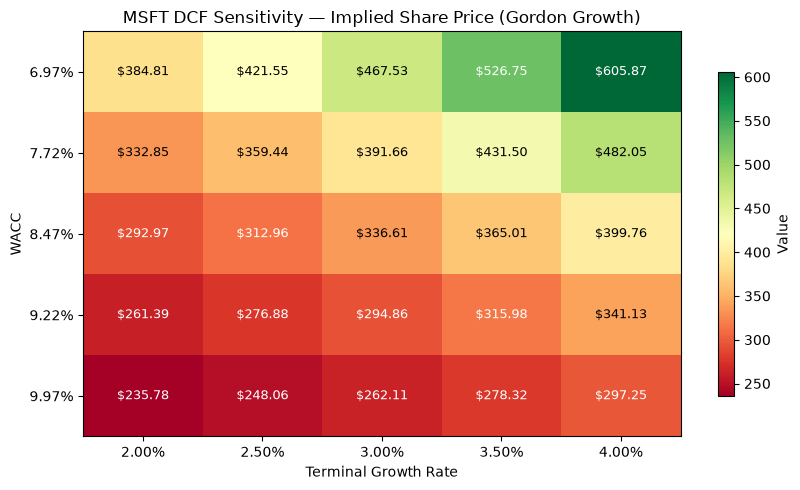

In [8]:
fig = dcf.plot_sensitivity_heatmap(grid, title=f"{TICKER} DCF Sensitivity — Implied Share Price (Gordon Growth)")
plt.show()

## 3. Trading Comparables

Filter an explicit peer candidate list down to genuine peers by sector and
market-cap range, pull EV/EBITDA, EV/Revenue, and P/E, and apply the peer
set's quartile multiples to MSFT's own financials.

In [9]:
candidate_tickers = ["AAPL", "GOOGL", "ORCL", "CRM", "ADBE", "IBM", "SAP", "NOW"]
peers = comps.select_peers(candidate_tickers, target_sector=company.sector, market_cap_range=(1e11, 1e14))
peers

,ticker,sector,market_cap
0,AAPL,Technology,"4,745,005,743,400.00"
1,ORCL,Technology,"407,068,161,720.00"
2,CRM,Technology,"212,424,530,000.00"
3,ADBE,Technology,"113,716,800,000.00"
4,IBM,Technology,"218,009,897,846.00"
5,SAP,Technology,"244,737,465,353.28"
6,NOW,Technology,"147,738,879,800.00"


In [10]:
peer_multiples = comps.fetch_peer_multiples(peers["ticker"].tolist())
peer_multiples

C:\Users\Irmak\OneDrive\Masaüstü\Code_vol1\valuation-toolkit\valuation\comps.py:111: UserWarning: 'SAP' quotes in USD but reports financials in EUR. This toolkit does not convert currencies -- functions that combine market data with financial-statement data for this company will raise until you resolve it via manual_overrides (see Company.assert_single_currency).
  company = build_company(ticker, years=1, use_cache=use_cache, refresh=refresh)


fetch_peer_multiples: 1 peer(s) had an issue computing EV: [('SAP', "'SAP' is quoted in USD but reports financials in EUR. This toolkit does not convert currencies -- combining market data (share price, market cap) with financial-statement data (EBITDA, revenue, net debt) here would silently produce a number wrong by roughly the FX rate. Resolve by supplying manual_overrides that put share_price/shares_outstanding and financials/net_debt in the same currency, then reconstruct the Company.")]


,ev_ebitda,ev_revenue,pe
ticker,,,
AAPL,33.21,11.55,37.24
ORCL,15.11,7.50,24.24
CRM,17.50,5.29,23.64
ADBE,11.67,4.82,16.36
IBM,15.37,3.93,20.55
SAP,NaN,NaN,27.25
NOW,48.45,11.03,89.31


Note SAP shows `NaN` for EV/EBITDA and EV/Revenue above (its P/E is
unaffected). This is intentional, not missing data: SAP quotes in USD via
its ADR but reports financial statements in EUR, and this toolkit detects
that mismatch (`Company.assert_single_currency`) and refuses to combine a
USD market cap with EUR-denominated EBITDA — a real bug found and fixed
while building this toolkit (see `LIMITATIONS.md`), not a hypothetical
edge case.

In [11]:
peer_stats = comps.summarize_peer_multiples(peer_multiples)
peer_stats

,ev_ebitda,ev_revenue,pe
mean,23.55,7.35,34.08
median,16.43,6.39,24.24
q1,15.17,4.93,22.09
q3,29.28,10.15,32.25
min,11.67,3.93,16.36
max,48.45,11.55,89.31
count,6.00,6.00,7.00


In [12]:
comps_valuation = comps.comps_valuation(company, peer_stats)
comps_valuation

,metric,stat,multiple,implied_ev,implied_equity_value,implied_share_price
0,ev_ebitda,q1,15.17,"3,148,886,472,849.33","3,129,527,472,849.33",421.45
1,ev_ebitda,median,16.43,"3,410,299,617,595.85","3,390,940,617,595.85",456.66
2,ev_ebitda,q3,29.28,"6,077,150,441,028.38","6,057,791,441,028.38",815.80
3,ev_ebitda,mean,23.55,"4,887,255,479,776.89","4,867,896,479,776.89",655.56
4,ev_revenue,q1,4.93,"1,637,452,786,940.58","1,618,093,786,940.58",217.91
5,ev_revenue,median,6.39,"2,121,939,509,711.86","2,102,580,509,711.86",283.16
6,ev_revenue,q3,10.15,"3,366,753,585,676.58","3,347,394,585,676.58",450.79
7,ev_revenue,mean,7.35,"2,440,092,860,904.22","2,420,733,860,904.22",326.00


## 4. Precedent Transactions

Live precedent-transaction data isn't freely available via API — this
applies the median/quartile EV/EBITDA multiples paid in **six real,
individually-sourced enterprise-software M&A deals** (2014–2022; see
`data/precedent_transactions.csv` for each deal's source citation and
notes) to MSFT's own EBITDA.

In [13]:
transactions = pt.load_precedent_transactions()
transactions[["announcement_date", "acquirer", "target", "ev_ebitda"]]

,announcement_date,acquirer,target,ev_ebitda
0,2018-07-11,Broadcom,CA Technologies,12.40
1,2019-08-08,Broadcom,Symantec (Enterprise Security business),30.60
2,2022-05-26,Broadcom,VMware,13.00
3,2022-01-31,Vista Equity Partners / Evergreen Coast Capital,Citrix Systems,24.80
4,2014-09-29,Vista Equity Partners,TIBCO Software,18.00
5,2016-09-07,Micro Focus,Hewlett Packard Enterprise Software business,11.40


In [14]:
txn_stats = pt.summarize_transaction_multiples(transactions)
precedent_valuation = pt.precedent_valuation(company, txn_stats)
precedent_valuation

,metric,stat,multiple,implied_ev,implied_equity_value,implied_share_price
0,ev_ebitda,q1,12.55,"2,604,363,450,000.00","2,585,004,450,000.00",348.12
1,ev_ebitda,median,15.50,"3,216,544,500,000.00","3,197,185,500,000.00",430.57
2,ev_ebitda,q3,23.10,"4,793,688,900,000.00","4,774,329,900,000.00",642.96
3,ev_ebitda,mean,18.37,"3,811,432,300,000.00","3,792,073,300,000.00",510.68


In [15]:
premium = pt.control_premium(txn_stats, peer_stats)
print(f"Precedent-transaction median EV/EBITDA vs. today's trading-comps median: {premium:+.1%}")

Precedent-transaction median EV/EBITDA vs. today's trading-comps median: -5.7%


**This comes out negative, and that's worth sitting with rather than
explaining away.** The textbook expectation is that acquirers pay a
*positive* premium over where comparable public companies trade, to
acquire control. Here the curated deal set (2014–2022, legacy enterprise
infrastructure software — several of these were value-multiple take-
privates, not growth premiums) is being compared against a *current*
trading-comps peer set that includes richly-rated, higher-growth names.
The negative number is the vintage/growth-profile mismatch between the two
inputs showing up, not evidence the control-premium concept is wrong — see
`control_premium()`'s docstring and `LIMITATIONS.md` for the full
reasoning. A cleaner read would require sourcing precedent deals from
roughly the same period as the trading comps.

### Football Field: DCF vs. Comps vs. Precedent Transactions

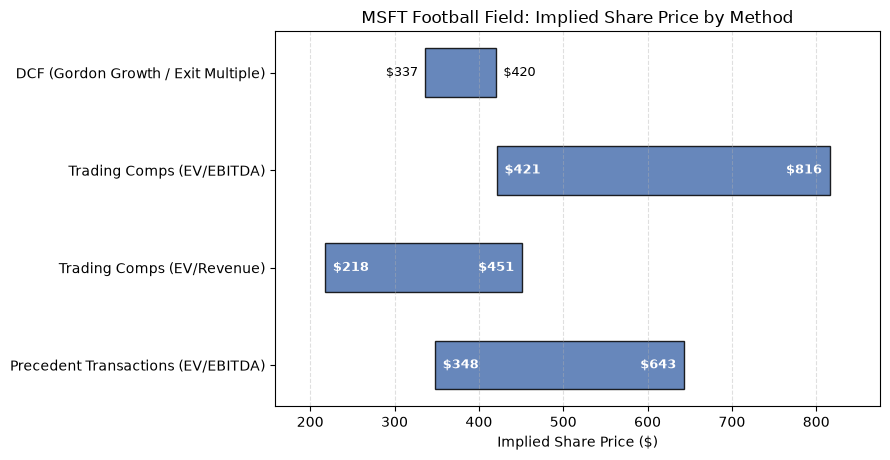

For reference, MSFT's actual current share price: $501.02


In [16]:
ranges = {
    "DCF (Gordon Growth / Exit Multiple)": (
        min(result.implied_share_price_gordon, result.implied_share_price_exit),
        max(result.implied_share_price_gordon, result.implied_share_price_exit),
    ),
    "Trading Comps (EV/EBITDA)": comps.implied_share_price_range(comps_valuation, "ev_ebitda"),
    "Trading Comps (EV/Revenue)": comps.implied_share_price_range(comps_valuation, "ev_revenue"),
    "Precedent Transactions (EV/EBITDA)": comps.implied_share_price_range(precedent_valuation, "ev_ebitda"),
}
fig = comps.plot_football_field(ranges, title=f"{TICKER} Football Field: Implied Share Price by Method")
plt.show()
print(f"For reference, {TICKER}'s actual current share price: ${company.share_price:,.2f}")

## 5. Credit Overlay — the differentiator

Every method above answers "what is this company worth?" This section
takes that Enterprise Value and asks what a direct lender actually asks:
at various leverage levels a lender might underwrite to, what's the debt
quantum, is interest coverage adequate, how much equity cushion sits below
the debt — and in a downside (EBITDA down 25%, exit multiple compressed
15%), what does each leverage tranche actually recover?

We use the DCF Exit Multiple EV as the base case here, since exit
multiples are the more directly comparable convention to how a leverage
lender itself thinks about EV.

In [17]:
base_ev = result.ev_exit
print(f"Enterprise Value used for credit overlay (DCF, Exit Multiple): ${base_ev:,.0f}")

leverage = co.leverage_analysis(
    company,
    base_ev,
    leverage_levels=(3.0, 4.0, 5.0, 6.0),
    interest_rate=[0.07, 0.08, 0.09, 0.11],  # wider spread priced in at higher leverage
)
leverage

Enterprise Value used for credit overlay (DCF, Exit Multiple): $3,138,938,242,174


,ebitda,debt_quantum,interest_rate,interest_expense,interest_coverage,enterprise_value,equity_cushion,equity_cushion_pct_of_ev,below_2.0x_covenant,below_2.5x_covenant
leverage_x,,,,,,,,,,
3.00,"207,519,000,000.00","622,557,000,000.00",0.07,"43,578,990,000.00",4.76,"3,138,938,242,173.85","2,516,381,242,173.85",0.80,False,False
4.00,"207,519,000,000.00","830,076,000,000.00",0.08,"66,406,080,000.00",3.12,"3,138,938,242,173.85","2,308,862,242,173.85",0.74,False,False
5.00,"207,519,000,000.00","1,037,595,000,000.00",0.09,"93,383,550,000.00",2.22,"3,138,938,242,173.85","2,101,343,242,173.85",0.67,False,True
6.00,"207,519,000,000.00","1,245,114,000,000.00",0.11,"136,962,540,000.00",1.52,"3,138,938,242,173.85","1,893,824,242,173.85",0.60,True,True


In [18]:
downside = co.downside_recovery(
    company,
    leverage_levels=(3.0, 4.0, 5.0, 6.0),
    ebitda_decline=0.25,          # a severe but not implausible cyclical stress
    exit_multiple=14.0,           # same base-case multiple as the DCF, for consistency
    multiple_compression=0.15,    # distressed businesses trade cheaper too, not just earn less
)
downside

,debt_quantum,base_ebitda,stressed_ebitda,exit_multiple,stressed_multiple,stressed_ev,recovery_value,recovery_pct,equity_value_in_stress,equity_wiped_out
leverage_x,,,,,,,,,,
3.00,"622,557,000,000.00","207,519,000,000.00","155,639,250,000.00",14.00,11.90,"1,852,107,075,000.00","622,557,000,000.00",1.00,"1,229,550,075,000.00",False
4.00,"830,076,000,000.00","207,519,000,000.00","155,639,250,000.00",14.00,11.90,"1,852,107,075,000.00","830,076,000,000.00",1.00,"1,022,031,075,000.00",False
5.00,"1,037,595,000,000.00","207,519,000,000.00","155,639,250,000.00",14.00,11.90,"1,852,107,075,000.00","1,037,595,000,000.00",1.00,"814,512,075,000.00",False
6.00,"1,245,114,000,000.00","207,519,000,000.00","155,639,250,000.00",14.00,11.90,"1,852,107,075,000.00","1,245,114,000,000.00",1.00,"606,993,075,000.00",False


In [19]:
credit_summary = co.credit_summary_table(leverage, downside)
credit_summary

,debt_quantum,interest_coverage,equity_cushion_pct_of_ev,recovery_pct,equity_wiped_out,below_2.0x_covenant,below_2.5x_covenant
leverage_x,,,,,,,
3.00,"622,557,000,000.00",4.76,0.80,1.00,False,False,False
4.00,"830,076,000,000.00",3.12,0.74,1.00,False,False,False
5.00,"1,037,595,000,000.00",2.22,0.67,1.00,False,False,True
6.00,"1,245,114,000,000.00",1.52,0.60,1.00,False,True,True


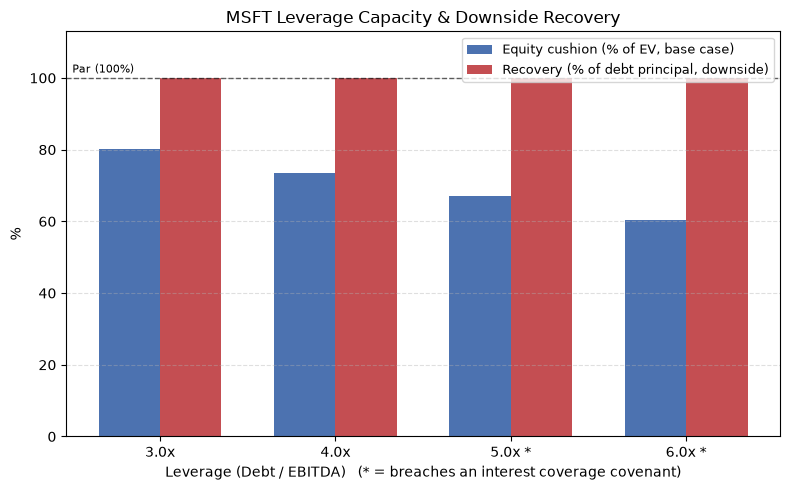

In [20]:
fig = co.plot_leverage_recovery(credit_summary, title=f"{TICKER} Leverage Capacity & Downside Recovery")
plt.show()

**The finding here is itself informative.** Even at 6x leverage, combined
with a 25% EBITDA decline *and* 15% multiple compression, recovery stays
at 100% — MSFT's EV is so large relative to any plausible debt quantum
that recovery risk essentially never binds. What actually constrains
leverage here is **interest coverage**: the 2.5x covenant is breached at
5x and 6x leverage (marked with `*` above) well before recovery becomes a
concern. This is a real, credit-relevant conclusion, not a limitation of
the tool: it's exactly why direct lenders don't underwrite mega-cap tech
to 6x in practice — the constraint that actually bites is cash-flow
coverage of debt service, not asset coverage. A mid-cap or more
leverage-typical borrower would show a very different picture, with both
constraints binding much closer together.

## Synthesis

**Equity perspective:** across all four ranges, implied share price spans
roughly $218 (trading comps' EV/Revenue low end) to $816 (trading comps'
EV/EBITDA high end) — a spread that says more about how dispersed the
peer set's own trading multiples are than about MSFT specifically. The
DCF produces the tightest, most conservative range ($337–$420), with
precedent transactions overlapping just above it ($348–$643). MSFT's
actual current share price (~$501, printed above) sits *above* both the
DCF and EV/Revenue-implied ranges, but comfortably inside the EV/EBITDA
and precedent-transaction ranges — consistent with the market currently
pricing MSFT closer to how richly its highest-multiple peers (Apple,
ServiceNow) trade than to what a DCF built on explicit, conservative
assumptions would imply.

**Credit perspective:** MSFT can support significant leverage on a pure
recovery basis — even a severe combined stress (25% EBITDA decline, 15%
multiple compression) leaves lenders whole at 6x. But interest coverage
covenants bind well before that, breaching a 2.5x minimum at 5x leverage
and a 2.0x minimum at 6x. For a company at this scale and quality, the
binding credit constraint is cash-flow coverage, not asset/recovery risk —
the opposite of what tends to bind for a smaller, more leveraged borrower,
and a good illustration of why "how much debt can this support" and "how
much debt is safe" are different questions with different answers.